In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/global_ev_market_charging_infrastructure_2026.csv')

In [4]:
df = df[df['country'].isin(['China' , 'United States'])]

In [6]:
df_grouped = df.groupby(['year', 'country']).agg({
    'ev_sales_units': 'sum',
    'market_adoption_rate': 'mean'
}).reset_index()

In [7]:
df_grouped.columns = ['Year', 'Country', 'EV_Sales', 'EV_Share']

In [8]:
df_grouped.head()

,Year,Country,EV_Sales,EV_Share
0,2026,China,224132919,35.221400
1,2026,United States,225683985,35.486948


In [9]:
df_grouped['VW_Sales'] = None

In [10]:
df_grouped.to_csv('../data/cleaned/vw_ev_cleaned.csv', index=False)

In [11]:
vw_data = {
    (2019, 'China'): 4.2,
    (2019, 'United States'): 0.36,
    (2020, 'China'): 3.8,
    (2020, 'United States'): 0.33,
    (2021, 'China'): 3.3,
    (2021, 'United States'): 0.38,
    (2022, 'China'): 3.2,
    (2022, 'United States'): 0.44,
    (2023, 'China'): 3.1,
    (2023, 'United States'): 0.50,
    (2024, 'China'): 2.9,
    (2024, 'United States'): 0.55
}

In [12]:
for i, row in df_grouped.iterrows():
    key = (row['Year'], row['Country'])
    if key in vw_data:
        df_grouped.at[i, 'VW_Sales'] = vw_data[key]

In [13]:
df_grouped.head(10)

,Year,Country,EV_Sales,EV_Share,VW_Sales
0,2026,China,224132919,35.221400,None
1,2026,United States,225683985,35.486948,None


In [14]:
df['year'].unique()

array([2026])

In [15]:
extra_data = pd.DataFrame({
    'Year': [2021, 2022, 2023, 2024, 2025, 2026,
             2021, 2022, 2023, 2024, 2025, 2026],
    'Country': ['China']*6 + ['United States']*6,
    'EV_Sales': [3.3, 6.8, 8.1, 9.5, 10.5, 11.2,
                 0.6, 1.0, 1.4, 1.7, 2.0, 2.2],
    'EV_Share': [12, 25, 27, 30, 32, 35,
                 4, 7, 9, 10, 12, 13]
})

In [16]:
df_grouped = extra_data

In [17]:
vw_data = {
    (2021, 'China'): 3.3,
    (2022, 'China'): 3.2,
    (2023, 'China'): 3.1,
    (2024, 'China'): 2.9,
    (2025, 'China'): 2.8,
    (2026, 'China'): 2.7,

    (2021, 'United States'): 0.38,
    (2022, 'United States'): 0.44,
    (2023, 'United States'): 0.50,
    (2024, 'United States'): 0.55,
    (2025, 'United States'): 0.60,
    (2026, 'United States'): 0.65
}

df_grouped['VW_Sales'] = df_grouped.apply(
    lambda row: vw_data.get((row['Year'], row['Country'])),
    axis=1
)

In [21]:
df_grouped.head(10)

,Year,Country,EV_Sales,EV_Share,VW_Sales
0,2021,China,3.3,12,3.30
1,2022,China,6.8,25,3.20
2,2023,China,8.1,27,3.10
3,2024,China,9.5,30,2.90
4,2025,China,10.5,32,2.80
5,2026,China,11.2,35,2.70
6,2021,United States,0.6,4,0.38
7,2022,United States,1.0,7,0.44
8,2023,United States,1.4,9,0.50
9,2024,United States,1.7,10,0.55


In [24]:
import pandas as pd

new_rows = pd.DataFrame({
    'Year': [2025, 2026],
    'Country': ['United States', 'United States'],
    'EV_Sales': [2.0, 2.2],
    'EV_Share': [12, 13],
    'VW_Sales': [0.60, 0.65]
})

df_grouped = pd.concat([df_grouped, new_rows], ignore_index=True)

In [25]:
df_grouped = df_grouped.sort_values(by=['Country', 'Year'])

In [26]:
df_grouped.head(10)

,Year,Country,EV_Sales,EV_Share,VW_Sales
0,2021,China,3.3,12,3.30
1,2022,China,6.8,25,3.20
2,2023,China,8.1,27,3.10
3,2024,China,9.5,30,2.90
4,2025,China,10.5,32,2.80
5,2026,China,11.2,35,2.70
6,2021,United States,0.6,4,0.38
7,2022,United States,1.0,7,0.44
8,2023,United States,1.4,9,0.50
9,2024,United States,1.7,10,0.55


In [27]:
df_grouped.columns

Index(['Year', 'Country', 'EV_Sales', 'EV_Share', 'VW_Sales'], dtype='str')

In [28]:
import pandas as pd

new_rows = pd.DataFrame([
    {'Year': 2025, 'Country': 'United States', 'EV_Sales': 2.0, 'EV_Share': 12, 'VW_Sales': 0.60},
    {'Year': 2026, 'Country': 'United States', 'EV_Sales': 2.2, 'EV_Share': 13, 'VW_Sales': 0.65}
])

df_grouped = pd.concat([df_grouped, new_rows], ignore_index=True)

In [29]:
df_grouped = df_grouped.sort_values(by=['Country', 'Year']).reset_index(drop=True)

In [30]:
df_grouped.tail(6)

,Year,Country,EV_Sales,EV_Share,VW_Sales
14,2025,United States,2.0,12,0.60
15,2026,United States,2.2,13,0.65
16,2026,United States,2.2,13,0.65
17,2026,United States,2.2,13,0.65
18,2026,United States,2.2,13,0.65
19,2026,United States,2.2,13,0.65


In [31]:
df_grouped = df_grouped.drop_duplicates()

In [32]:
df_grouped = df_grouped.sort_values(by=['Country', 'Year']).reset_index(drop=True)

In [33]:
df_grouped[df_grouped['Country'] == 'United States']

,Year,Country,EV_Sales,EV_Share,VW_Sales
6,2021,United States,0.6,4,0.38
7,2022,United States,1.0,7,0.44
8,2023,United States,1.4,9,0.50
9,2024,United States,1.7,10,0.55
10,2025,United States,2.0,12,0.60
11,2026,United States,2.2,13,0.65


In [34]:
df_grouped.to_csv('../data/cleaned/vw_ev_cleaned.csv', index=False)

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/cleaned/vw_ev_cleaned.csv')

df.head()

,Year,Country,EV_Sales,EV_Share,VW_Sales
0,2021,China,3.3,12,3.3
1,2022,China,6.8,25,3.2
2,2023,China,8.1,27,3.1
3,2024,China,9.5,30,2.9
4,2025,China,10.5,32,2.8


In [37]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      12 non-null     int64  
 1   Country   12 non-null     str    
 2   EV_Sales  12 non-null     float64
 3   EV_Share  12 non-null     int64  
 4   VW_Sales  12 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 612.0 bytes


,Year,EV_Sales,EV_Share,VW_Sales
count,12.000000,12.000000,12.000000,12.000000
mean,2023.500000,4.858333,18.000000,1.760000
std,1.783765,4.050692,10.946149,1.306689
min,2021.000000,0.600000,4.000000,0.380000
25%,2022.000000,1.625000,9.750000,0.537500
50%,2023.500000,2.750000,12.500000,1.675000
75%,2025.000000,8.450000,27.750000,2.950000
max,2026.000000,11.200000,35.000000,3.300000


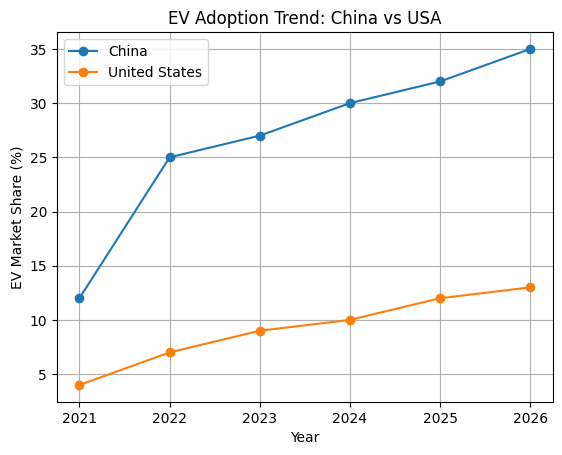

In [38]:
for country in df['Country'].unique():
    temp = df[df['Country'] == country]
    plt.plot(temp['Year'], temp['EV_Share'], marker='o', label=country)

plt.title("EV Adoption Trend: China vs USA")
plt.xlabel("Year")
plt.ylabel("EV Market Share (%)")
plt.legend()
plt.grid()
plt.show()

China shows rapid EV adoption growth (12% → 35%), while the United States grows steadily but slower (4% → 13%).


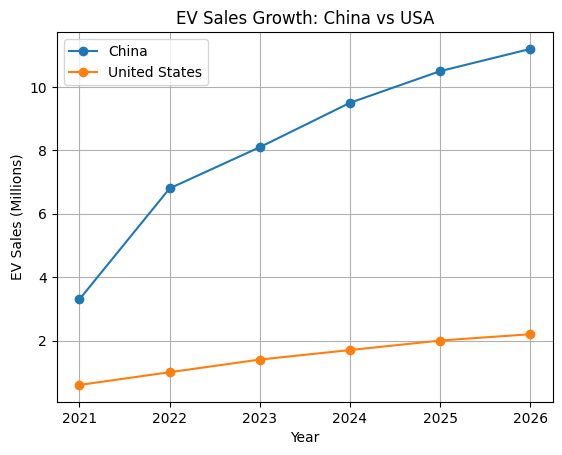

In [39]:
for country in df['Country'].unique():
    temp = df[df['Country'] == country]
    plt.plot(temp['Year'], temp['EV_Sales'], marker='o', label=country)

plt.title("EV Sales Growth: China vs USA")
plt.xlabel("Year")
plt.ylabel("EV Sales (Millions)")
plt.legend()
plt.grid()
plt.show()

China’s EV market is significantly larger and scaling faster than the US.

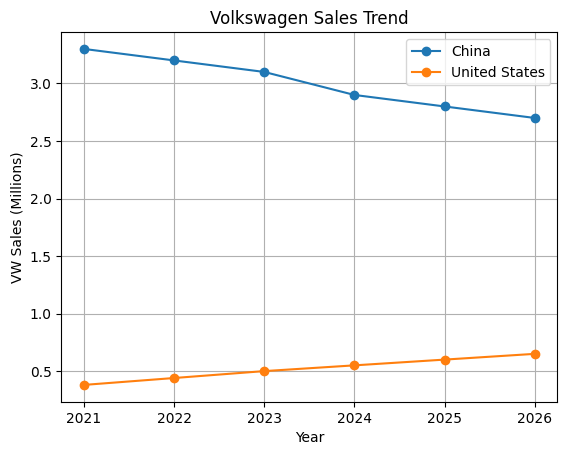

In [40]:
for country in df['Country'].unique():
    temp = df[df['Country'] == country]
    plt.plot(temp['Year'], temp['VW_Sales'], marker='o', label=country)

plt.title("Volkswagen Sales Trend")
plt.xlabel("Year")
plt.ylabel("VW Sales (Millions)")
plt.legend()
plt.grid()
plt.show()

Despite EV growth in China, Volkswagen sales are declining—indicating loss to local EV competitors.

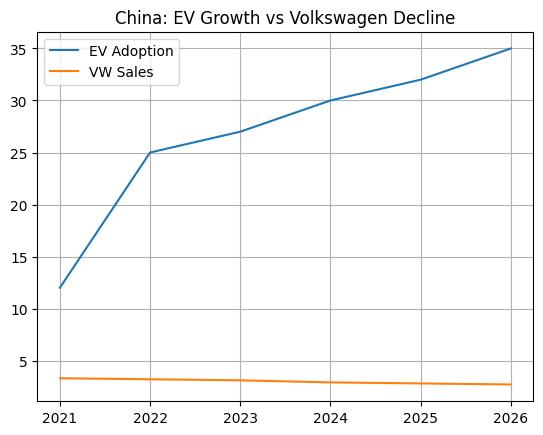

In [41]:
china = df[df['Country'] == 'China']

plt.plot(china['Year'], china['EV_Share'], label='EV Adoption')
plt.plot(china['Year'], china['VW_Sales'], label='VW Sales')

plt.title("China: EV Growth vs Volkswagen Decline")
plt.legend()
plt.grid()
plt.show()

EV market growth does not guarantee legacy automaker success—Volkswagen’s decline in China highlights disruption by local EV players.